In [16]:
from pathlib import Path

BASE_DIR = Path().resolve()

while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

print(BASE_DIR)

C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN


In [17]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path().resolve().parent

data_path = BASE_DIR / "data" / "original_data" / "pivot_25stations.csv"

df = pd.read_csv(data_path)
df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])
df = df.set_index(df.columns[0])
df = df[df.index >= "1980-01-01"]
annual_max = df.resample("A").max()
print(annual_max)

            ALISHAN  ANBU  CHENGGONG  CHIAYI  DAWU  DONGJIDAO  HENGCHUN  \
Date                                                                      
1980-12-31     14.8  24.0       28.3    29.0  29.2       28.5      29.4   
1981-12-31     14.6  23.4       28.7    28.5  29.2       28.1      28.8   
1982-12-31     14.7  22.8       28.2    28.3  28.5       27.6      27.9   
1983-12-31     15.0  23.9       29.0    29.6  29.7       29.4      29.2   
1984-12-31     14.4  23.8       28.0    28.4  28.4       28.0      28.1   
1985-12-31     14.1  22.4       27.7    28.2  28.0       27.8      27.7   
1986-12-31     14.2  23.0       28.1    28.7  28.5       28.1      27.7   
1987-12-31     14.5  23.4       28.3    28.8  28.8       28.7      28.8   
1988-12-31     14.6  23.8       28.6    28.7  28.6       28.4      28.5   
1989-12-31     14.3  23.1       28.1    28.4  28.4       28.6      28.8   
1990-12-31     14.6  23.1       28.1    28.5  29.0       28.2      28.3   
1991-12-31     14.7  23.5

c:\Users\User.DESKTOP-4RV84M1\miniconda3\envs\31011\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
C:\Users\User.DESKTOP-4RV84M1\AppData\Local\Temp\ipykernel_1972\1994195231.py:12: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_max = df.resample("A").max()


In [18]:
import numpy as np

P_SET = np.array([0.0001, 0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999, 0.9999])

def robust_standardize(y):
    median = np.median(y)
    q25, q75 = np.percentile(y, [25, 75])
    iqr = q75 - q25
    return (y - median) / (iqr + 1e-12)

X_real = []

for col in annual_max.columns:
    y = annual_max[col].dropna().values
    if len(y) < 20:
        continue

    z = robust_standardize(y)
    q = np.percentile(z, P_SET * 100)

    X_real.append(q)

X_real = np.array(X_real, dtype=np.float32)

print("X_real shape:", X_real.shape)

X_real shape: (25, 11)


In [19]:
from pathlib import Path
import sys

import pandas as pd
import torch

BASE_DIR = Path().resolve()
while not (BASE_DIR / "data").exists():
    if BASE_DIR.parent == BASE_DIR:
        raise FileNotFoundError("Could not find project root containing data/")
    BASE_DIR = BASE_DIR.parent

SRC_DIR = BASE_DIR / "src"
MODEL_DIR = BASE_DIR / "models"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from baseline_train import GEVNet

device = "cuda" if torch.cuda.is_available() else "cpu"
model = GEVNet().to(device)

model_path = MODEL_DIR / "best_baseline_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

with torch.no_grad():
    preds = model(torch.from_numpy(X_real).float().to(device)).cpu().numpy()

pred_df = pd.DataFrame(preds, columns=["mu_star", "delta", "c"])
display(pred_df.head())


,mu_star,delta,c
0,-0.142109,-1.186031,0.168237
1,-0.169521,-1.630806,0.289228
2,-0.317484,-1.326132,0.317306
3,-0.302829,-0.784699,-0.082403
4,-0.259258,-1.001709,0.135035


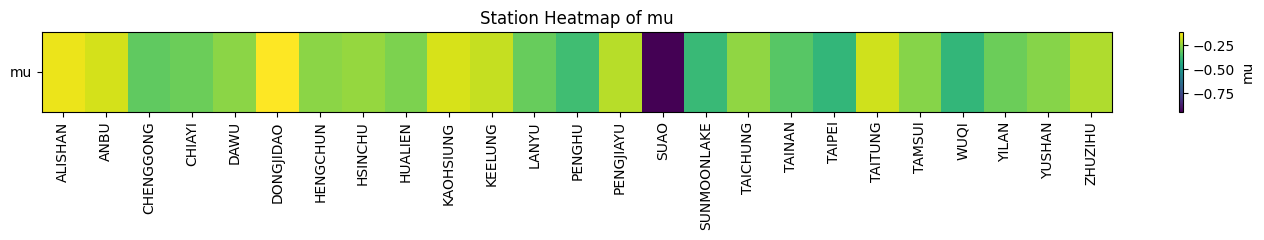

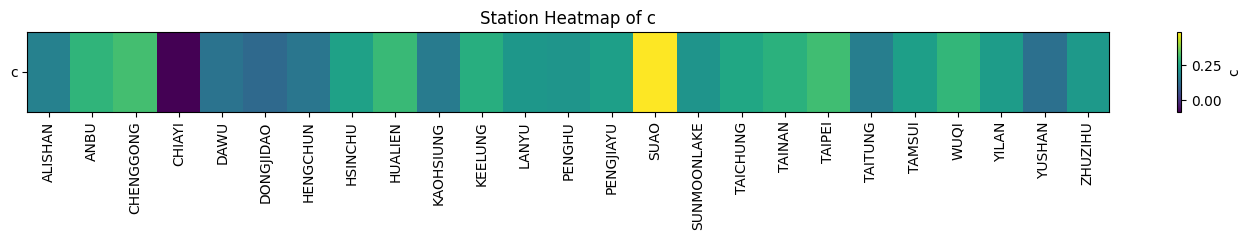

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

station_names = list(annual_max.columns[:len(preds)])

pred_df = pd.DataFrame({
    "station": station_names,
    "mu": preds[:, 0],
    "delta": preds[:, 1],
    "c": preds[:, 2],
})

# 轉成一列 heatmap
mu_heat = pred_df.set_index("station")[["mu"]].T
c_heat = pred_df.set_index("station")[["c"]].T

plt.figure(figsize=(14, 2.5))
plt.imshow(mu_heat, aspect="auto")
plt.xticks(range(len(mu_heat.columns)), mu_heat.columns, rotation=90)
plt.yticks([0], ["mu"])
plt.colorbar(label="mu")
plt.title("Station Heatmap of mu")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 2.5))
plt.imshow(c_heat, aspect="auto")
plt.xticks(range(len(c_heat.columns)), c_heat.columns, rotation=90)
plt.yticks([0], ["c"])
plt.colorbar(label="c")
plt.title("Station Heatmap of c")
plt.tight_layout()
plt.show()

In [21]:
coords = {
    "TAMSUI": (25.164888, 121.448906),
    "ANBU": (25.182587, 121.52973),
    "ZHUZIHU": (25.162079, 121.54455),
    "TAIPEI": (25.037659, 121.514854),
    "KEELUNG": (25.133314, 121.74048),
    "DONGJIDAO": (23.25695, 119.667465),
    "SU-AO": (24.596737, 121.85737),
    "YILAN": (24.763975, 121.75653),
    "HUALIEN": (23.975128, 121.61327),
    "PENGJIAYU": (25.627975, 122.07974),
    "PENGHU": (23.565502, 119.563095),
    "TAINAN": (22.993238, 120.20477),
    "KAOHSIUNG": (22.565992, 120.315735),
    "CHIAYI": (23.495926, 120.43291),
    "TAICHUNG": (24.145737, 120.684074),
    "HENGCHUN": (22.003897, 120.74634),
    "HSINCHU": (24.827852, 121.01422),
    "YUSHAN": (23.487614, 120.95952),
    "DAWU": (22.355675, 120.903786),
    "ALISHAN": (23.508207, 120.81324),
    "CHENGGONG": (23.097486, 121.37343),
    "LANYU": (22.036968, 121.55834),
    "SUN MOON LAKE": (23.881325, 120.90805),
    "TAITUNG": (22.75221, 121.15459),
    "WUQI": (24.256002, 120.523384),
}

coords_df = pd.DataFrame([
    {"station": k, "lat": v[0], "lon": v[1]}
    for k, v in coords.items()
])

coords_df.head()
plot_df = pred_df.merge(coords_df, on="station", how="inner")
plot_df

,station,mu,delta,c,lat,lon
0,ALISHAN,-0.142109,-1.186031,0.168237,23.508207,120.813240
1,ANBU,-0.169521,-1.630806,0.289228,25.182587,121.529730
2,CHENGGONG,-0.317484,-1.326132,0.317306,23.097486,121.373430
3,CHIAYI,-0.302829,-0.784699,-0.082403,23.495926,120.432910
4,DAWU,-0.259258,-1.001709,0.135035,22.355675,120.903786
5,DONGJIDAO,-0.117443,-1.220725,0.112743,23.256950,119.667465
6,HENGCHUN,-0.259020,-1.090986,0.140930,22.003897,120.746340
7,HSINCHU,-0.246971,-1.561513,0.243670,24.827852,121.014220
8,HUALIEN,-0.278793,-1.891938,0.303374,23.975128,121.613270
9,KAOHSIUNG,-0.166346,-0.847056,0.154375,22.565992,120.315735


## 畫 station heatmap

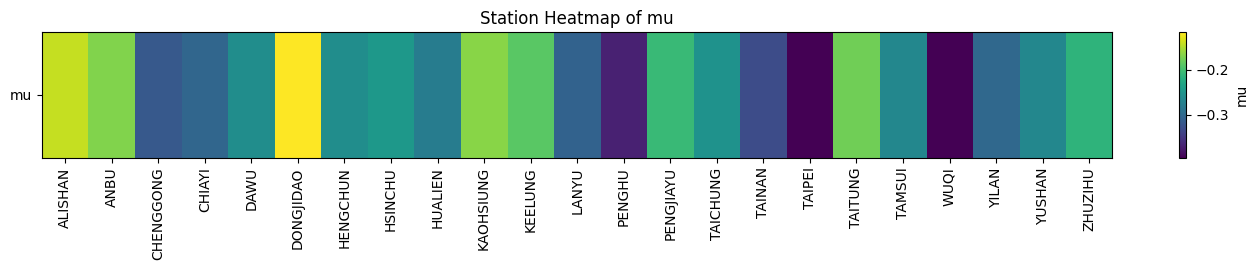

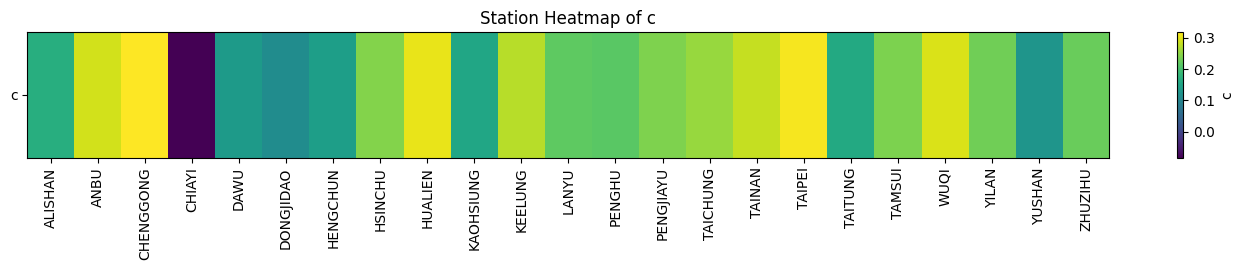

In [22]:
import matplotlib.pyplot as plt

mu_heat = plot_df.set_index("station")[["mu"]].T
c_heat = plot_df.set_index("station")[["c"]].T

plt.figure(figsize=(14, 2.8))
plt.imshow(mu_heat, aspect="auto")
plt.xticks(range(len(mu_heat.columns)), mu_heat.columns, rotation=90)
plt.yticks([0], ["mu"])
plt.colorbar(label="mu")
plt.title("Station Heatmap of mu")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 2.8))
plt.imshow(c_heat, aspect="auto")
plt.xticks(range(len(c_heat.columns)), c_heat.columns, rotation=90)
plt.yticks([0], ["c"])
plt.colorbar(label="c")
plt.title("Station Heatmap of c")
plt.tight_layout()
plt.show()

## 畫 $\mu$ spatial 分布

In [23]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

BASE_DIR = Path().resolve()

while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

shp_path = (
    BASE_DIR
    / "data"
    / "shapefile"
    / "ne_50m_admin_0_countries"
    / "ne_50m_admin_0_countries.shp"
)

world = gpd.read_file(shp_path)

taiwan = world[world["NAME"].str.contains("Taiwan", case=False, na=False)]

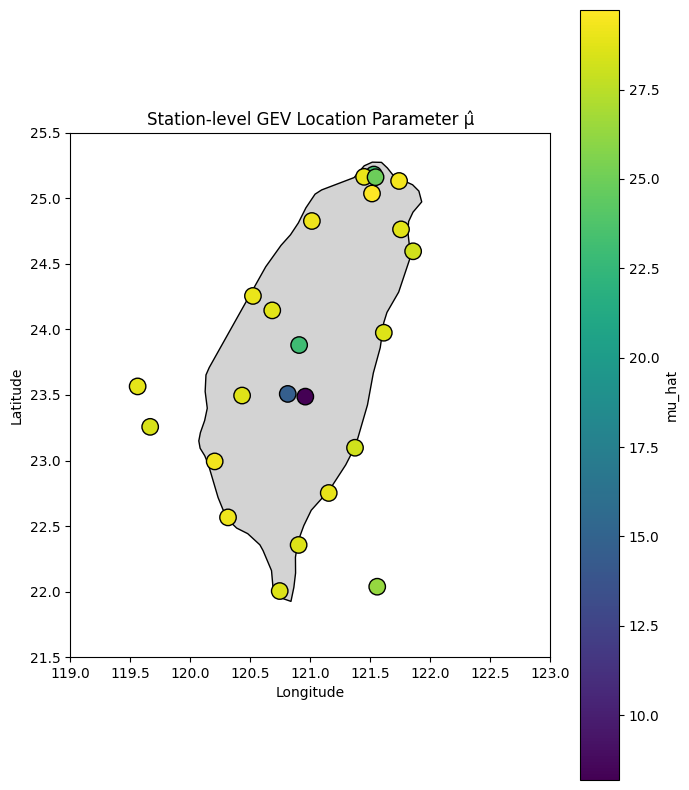

In [24]:
plot_df = pd.read_csv(BASE_DIR / "data" / "processed" / "station_gev_params_with_loc.csv")

fig, ax = plt.subplots(figsize=(7, 8))

taiwan.plot(ax=ax, color="lightgray", edgecolor="black")

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["mu_hat"],
    s=140,
    cmap="viridis",
    edgecolor="black"
)

plt.colorbar(sc, ax=ax, label="mu_hat")

ax.set_xlim(119, 123)
ax.set_ylim(21.5, 25.5)
ax.set_title("Station-level GEV Location Parameter μ̂")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

plot_df = pd.read_csv("../data/processed/station_gev_params_with_loc.csv")

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["mu_hat"],
    s=140,
    cmap="viridis",
    edgecolor="black"
)

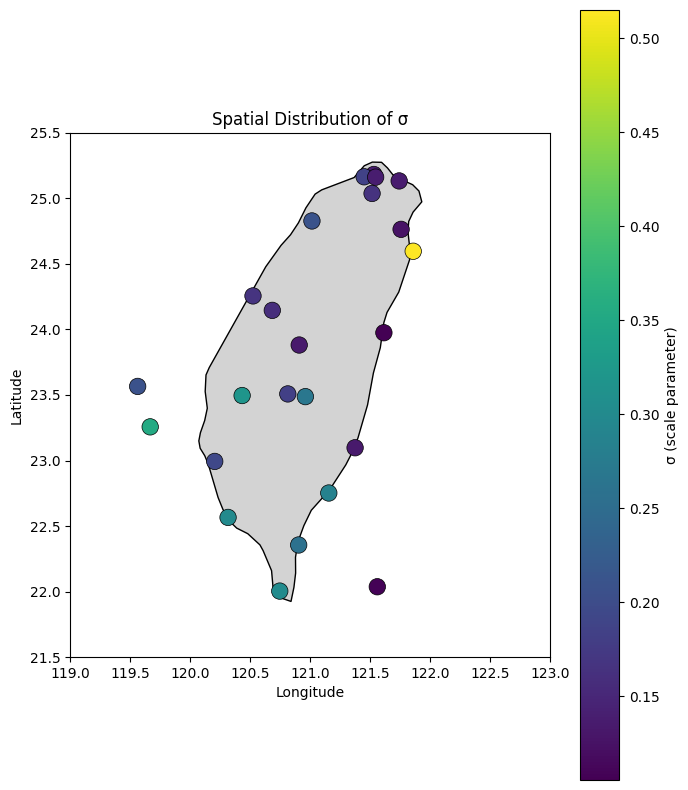

In [26]:
fig, ax = plt.subplots(figsize=(7, 8))

# 台灣底圖
taiwan.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black"
)

# 使用已還原 sigma
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["sigma_hat"],
    s=140,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5
)

plt.colorbar(
    sc,
    ax=ax,
    label="σ (scale parameter)"
)

ax.set_xlim(119, 123)
ax.set_ylim(21.5, 25.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("Spatial Distribution of σ")

plt.tight_layout()
plt.show()

## 畫 $\xi$ spatial 分布

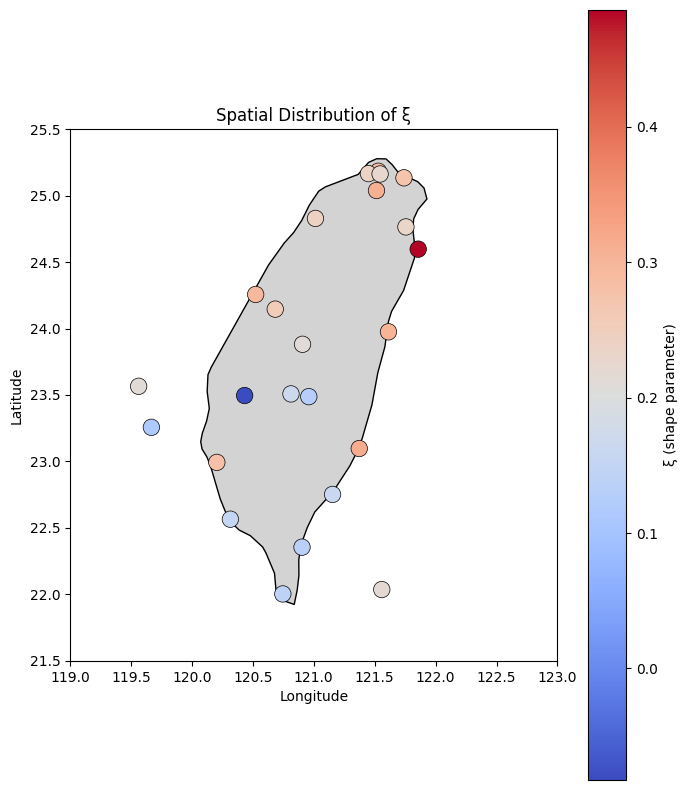

In [27]:
fig, ax = plt.subplots(figsize=(7, 8))

taiwan.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black"
)

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["xi_hat"],
    s=140,
    cmap="coolwarm",
    edgecolor="black",
    linewidth=0.5
)

plt.colorbar(
    sc,
    ax=ax,
    label="ξ (shape parameter)"
)

ax.set_xlim(119, 123)
ax.set_ylim(21.5, 25.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("Spatial Distribution of ξ")

plt.tight_layout()
plt.show()

## Bootstrap-NN 與 ML 比較

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

nn = pd.read_csv(
    BASE_DIR / "data" / "processed" / "nn_bootstrap_results.csv"
)
ml = pd.read_csv(
    BASE_DIR / "data" / "processed" / "mle_results.csv"
)

df = nn.merge(ml, on=["panel", "true_value", "rep"], how="inner")

df["ratio_mu"] = df["nn_width_mu"] / df["ml_width_mu"]
df["ratio_sigma"] = df["nn_width_sigma"] / df["ml_width_sigma"]
df["ratio_xi"] = df["nn_width_xi"] / df["ml_width_xi"]

print(df.head())

  panel  true_value  rep  nn_width_mu  nn_width_sigma  nn_width_xi  \
0    mu         1.0    0     2.199462        2.020198     0.157918   
1    mu         1.0    1     2.393185        1.933007     0.166876   
2    mu         1.0    2     2.291024        2.013975     0.171327   
3    mu         1.0    3     2.108166        1.857379     0.171342   
4    mu         1.0    4     2.302342        2.095912     0.165588   

   ml_width_mu  ml_width_sigma  ml_width_xi  ratio_mu  ratio_sigma  ratio_xi  
0     2.149297        1.692871     0.163287  1.023340     1.193356  0.967120  
1     2.124921        1.671343     0.135475  1.126246     1.156559  1.231786  
2     2.180772        1.743291     0.159100  1.050557     1.155272  1.076850  
3     1.988206        1.568085     0.153767  1.060336     1.184489  1.114302  
4     2.158159        1.687933     0.147895  1.066809     1.241703  1.119634  


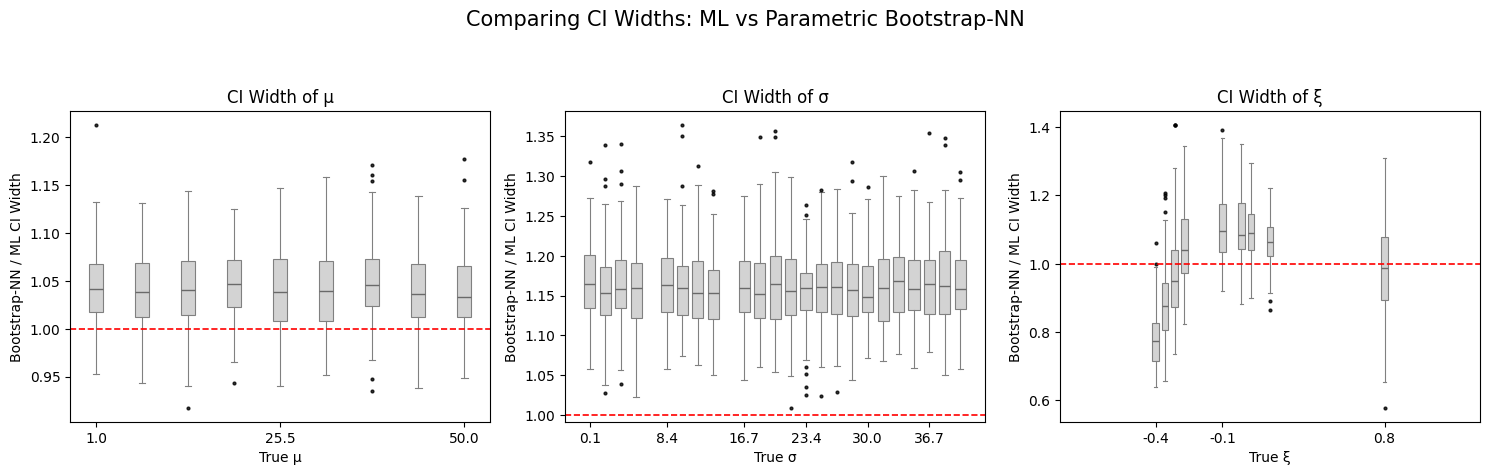

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("Comparing CI Widths: ML vs Parametric Bootstrap-NN", fontsize=15)

panel_info = [
    ("mu", "ratio_mu", "CI Width of μ", "True μ"),
    ("sigma", "ratio_sigma", "CI Width of σ", "True σ"),
    ("xi", "ratio_xi", "CI Width of ξ", "True ξ"),
]

for ax, (panel, ratio_col, title, xlabel) in zip(axes, panel_info):
    sub = df[df["panel"] == panel].copy()

    # 避免浮點數排序怪掉
    sub["true_value_round"] = sub["true_value"].round(3)
    x_vals = np.sort(sub["true_value_round"].unique())

    box_data = [
        sub.loc[sub["true_value_round"] == x, ratio_col].dropna().values
        for x in x_vals
    ]

    # box 寬度依 panel 個別調整
    if panel == "mu":
        width = 1.8
        tick_step = 4
        fmt = lambda v: f"{v:.1f}"
    elif panel == "sigma":
        width = 1.2
        tick_step = 4
        fmt = lambda v: f"{v:.1f}"
    else:  # xi
        width = 0.035
        tick_step = 4
        fmt = lambda v: f"{v:.1f}"

    ax.boxplot(
        box_data,
        positions=x_vals,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="lightgray", color="gray", linewidth=0.8),
        medianprops=dict(color="dimgray", linewidth=1.0),
        whiskerprops=dict(color="gray", linewidth=0.8),
        capprops=dict(color="gray", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=2,
            markerfacecolor="black",
            markeredgecolor="black",
            alpha=0.8
        )
    )

    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Bootstrap-NN / ML CI Width")

    # 只顯示部分 x 軸刻度，不然太擠
    tick_vals = x_vals[::tick_step]
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([fmt(v) for v in tick_vals], rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 對三個參數分別做 kriging 後 map 出來 

假設

$$
\mu(s)
=
x(s)^\top \beta_\mu + W_\mu(s)
$$

$$
\log\sigma(s)
=
x(s)^\top \beta_\sigma + W_\sigma(s)
$$

$$
\xi(s)
=
x(s)^\top \beta_\xi + W_\xi(s)
$$

其中

$$W_\mu(s) \sim GP(0, C_\mu(h))$$

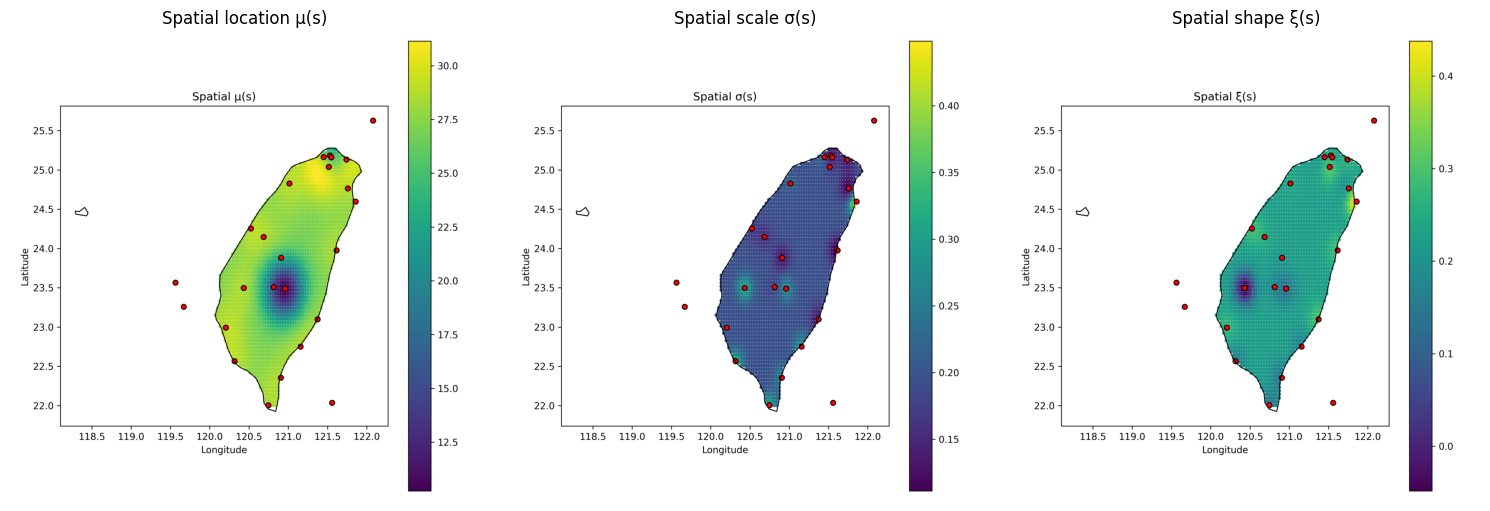

In [32]:
from pathlib import Path
import subprocess
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = Path().resolve()

while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

# Step 1: NN estimation
subprocess.run(
    ["python", str(BASE_DIR / "src" / "estimate_real_params.py")],
    check=True
)

# Step 2: merge location
subprocess.run(
    ["python", str(BASE_DIR / "src" / "merge_station_data.py")],
    check=True
)

# Step 3: Kriging
result = subprocess.run(
    ["python", str(BASE_DIR / "src" / "kriging_params.py")],
    capture_output=True,
    text=True,
    check=True,
)

# Step 4: plot
subprocess.run(
    ["python", str(BASE_DIR / "src" / "plot_gev_maps.py")],
    check=True
)

# Display maps as a 1 x 3 panel.
fig_dir = BASE_DIR / "results" / "figures"
fig_specs = [
    ("map_mu.png", "Spatial location μ(s)"),
    ("map_sigma.png", "Spatial scale σ(s)"),
    ("map_xi.png", "Spatial shape ξ(s)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, (filename, title) in zip(axes, fig_specs):
    img = mpimg.imread(fig_dir / filename)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.show()


## 計算 return_leval_surface

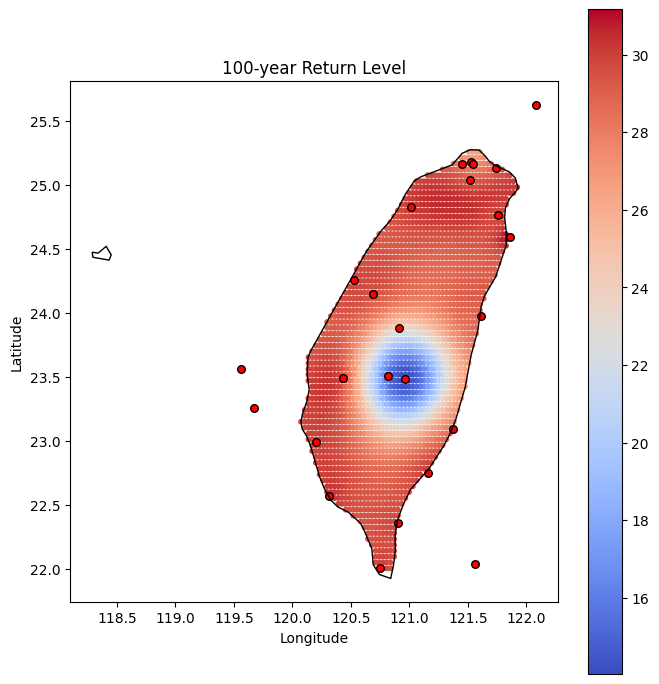

In [33]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# =========================
# 找 project root
# =========================
BASE_DIR = Path().resolve()

while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

# =========================
# 1. 執行 return level 計算
# =========================
os.system(f"python {BASE_DIR / 'src' / 'compute_return_level.py'}")

# =========================
# 2. 讀資料
# =========================
grid = pd.read_csv(BASE_DIR / "data" / "processed" / "grid_return_level.csv")
stations = pd.read_csv(BASE_DIR / "data" / "processed" / "station_gev_params_with_loc.csv")

# =========================
# 3. Taiwan shapefile
# =========================
shp_path = (
    BASE_DIR
    / "data"
    / "shapefile"
    / "ne_50m_admin_0_countries"
    / "ne_50m_admin_0_countries.shp"
)

world = gpd.read_file(shp_path)
taiwan = world[world["NAME"].str.contains("Taiwan", case=False, na=False)]

# =========================
# 4. grid → GeoDataFrame
# =========================
geometry = [Point(xy) for xy in zip(grid["lon"], grid["lat"])]
gdf = gpd.GeoDataFrame(grid, geometry=geometry, crs="EPSG:4326")

gdf_clipped = gpd.clip(gdf, taiwan)

# =========================
# 5. stations
# =========================
station_geom = [Point(xy) for xy in zip(stations["lon"], stations["lat"])]
stations_gdf = gpd.GeoDataFrame(stations, geometry=station_geom, crs="EPSG:4326")

# =========================
# 6. 畫圖
# =========================
fig, ax = plt.subplots(figsize=(7, 7))

taiwan.boundary.plot(ax=ax, color="black", linewidth=1)

gdf_clipped.plot(
    column="z_T",
    ax=ax,
    cmap="coolwarm",
    markersize=10,
    legend=True
)

stations_gdf.plot(
    ax=ax,
    color="red",
    markersize=30,
    edgecolor="black"
)

ax.set_title("100-year Return Level")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

## Spatial simulation validation

This section uses the same 25 station coordinates as the real data to create a simulated spatial GEV experiment with known true parameter fields. Annual maxima are generated from the known station-specific GEV parameters, then the existing NN estimator is combined with both RBF and Matérn Gaussian-process kriging. The maps are clipped to the Taiwan boundary so only simulated values inside Taiwan are shown.


,method,param,rmse,mae,correlation
0,RBF,mu,1.9606,1.4303,0.9755
1,RBF,sigma,4.0369,3.8273,0.0187
2,RBF,xi,0.0422,0.0319,0.0452
3,Matern,mu,1.9752,1.5140,0.9733
4,Matern,sigma,4.0367,3.8273,0.0236
5,Matern,xi,0.0420,0.0317,0.0494


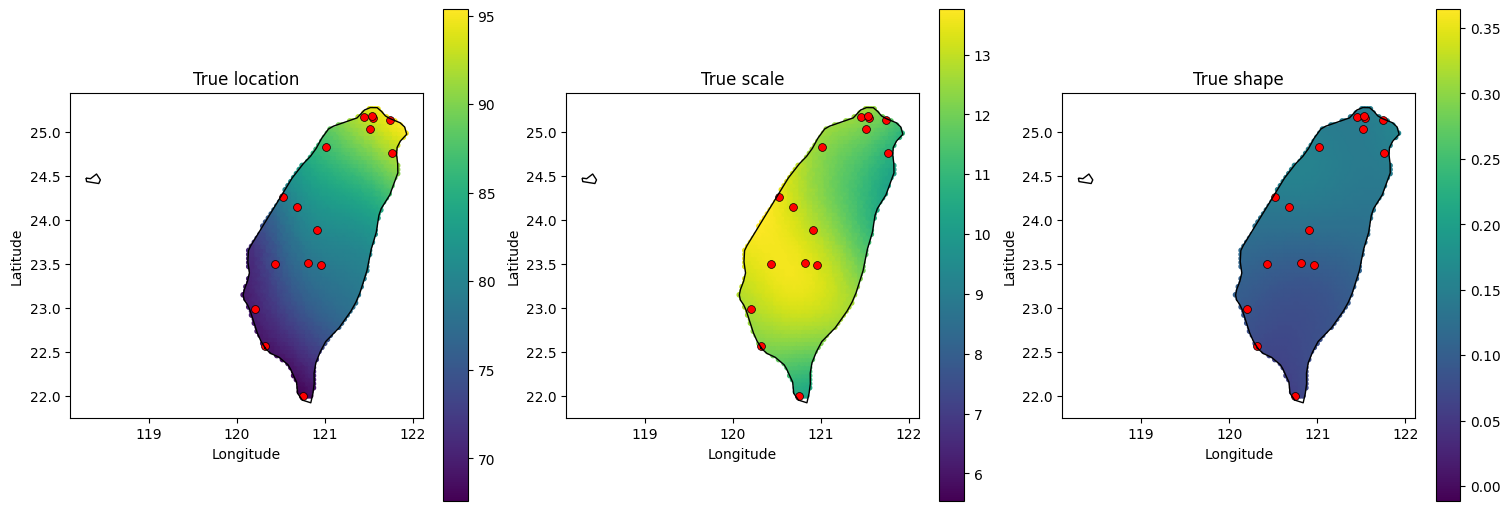

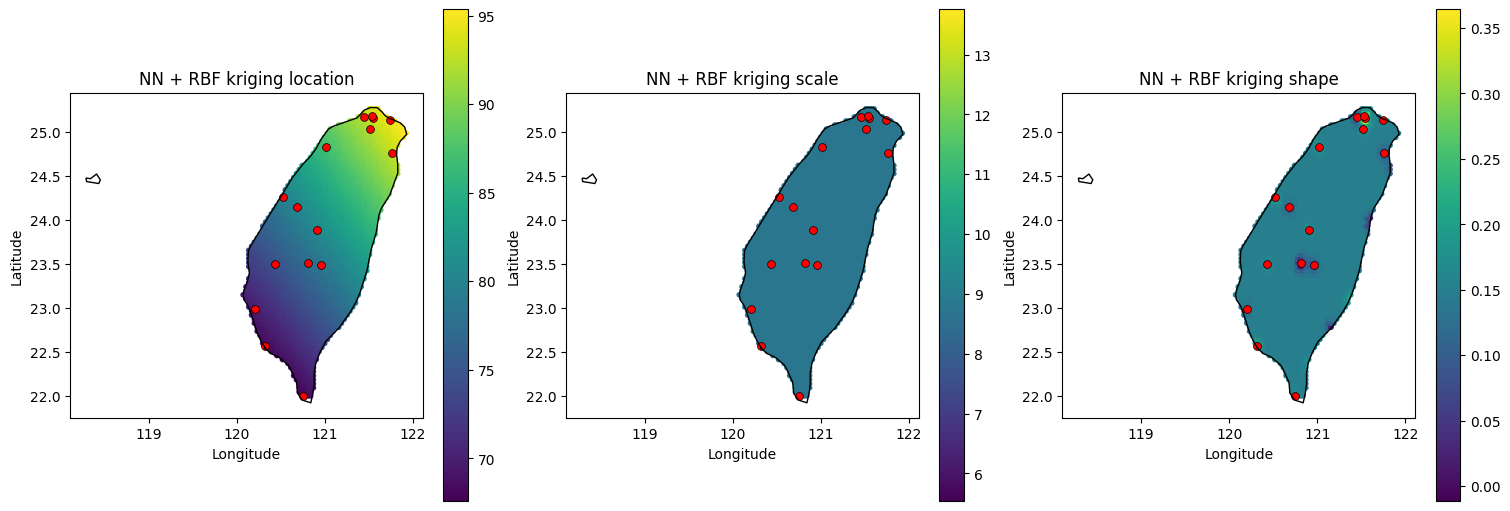

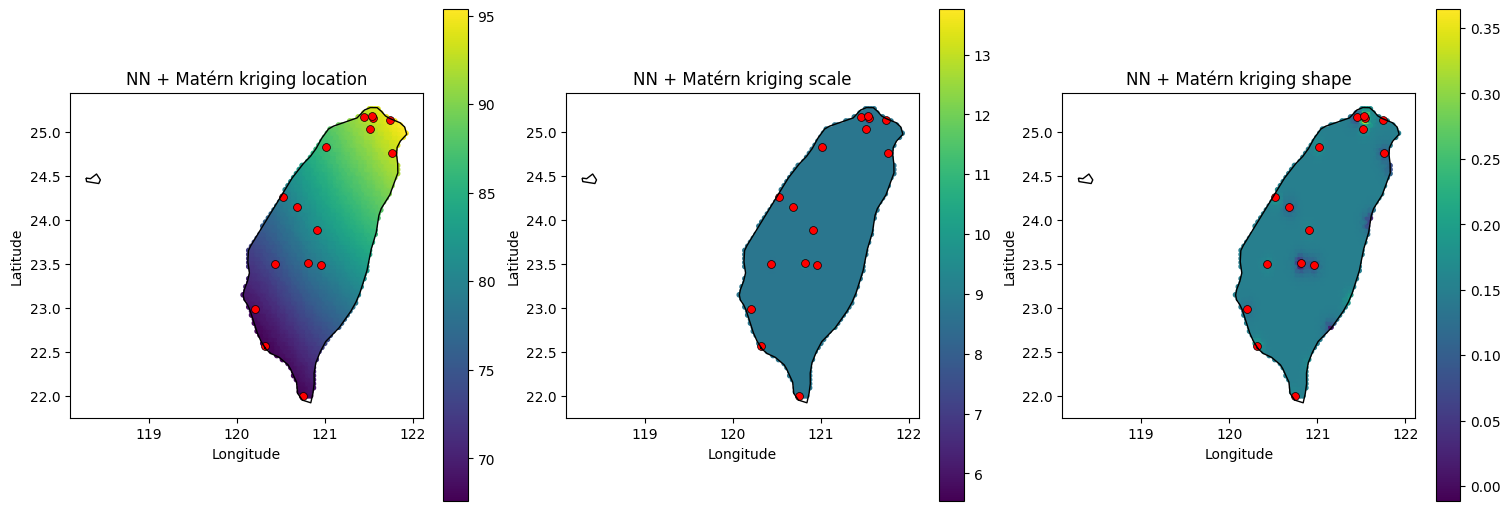

In [34]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

SRC_DIR = BASE_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

SIM_DIR = BASE_DIR / "data" / "simulated" / "spatial_gev"
true_grid_path = SIM_DIR / "spatial_grid_true_params.csv"
rbf_grid_path = SIM_DIR / "spatial_grid_nn_rbf_kriging_params.csv"
matern_grid_path = SIM_DIR / "spatial_grid_nn_matern_kriging_params.csv"
compare_path = SIM_DIR / "spatial_station_true_vs_nn.csv"
grid_summary_path = SIM_DIR / "spatial_grid_error_summary.csv"

required_true_cols = {"lon", "lat", "true_mu", "true_sigma", "true_xi"}
required_nn_cols = {"lon", "lat", "mu", "sigma", "xi"}
required_compare_cols = {"lon", "lat", "true_mu", "true_sigma", "true_xi", "mu_hat", "sigma_hat", "xi_hat"}

def run_spatial_simulation():
    import simulate_spatial_gev
    simulate_spatial_gev.main()

def has_required_columns(path, required_cols):
    if not path.exists():
        return False
    cols = set(pd.read_csv(path, nrows=0).columns)
    return required_cols.issubset(cols)

if not (
    has_required_columns(true_grid_path, required_true_cols)
    and has_required_columns(rbf_grid_path, required_nn_cols)
    and has_required_columns(matern_grid_path, required_nn_cols)
    and has_required_columns(compare_path, required_compare_cols)
    and grid_summary_path.exists()
):
    run_spatial_simulation()

true_grid = pd.read_csv(true_grid_path)
rbf_grid = pd.read_csv(rbf_grid_path)
matern_grid = pd.read_csv(matern_grid_path)
compare = pd.read_csv(compare_path)
grid_summary = pd.read_csv(grid_summary_path)

for df in (rbf_grid, matern_grid):
    df.rename(columns={"mu_hat": "mu", "sigma_hat": "sigma", "xi_hat": "xi"}, inplace=True)
    if "sigma" not in df.columns and "log_sigma" in df.columns:
        df["sigma"] = np.exp(df["log_sigma"])
if "true_sigma" not in true_grid.columns and "true_log_sigma" in true_grid.columns:
    true_grid["true_sigma"] = np.exp(true_grid["true_log_sigma"])

missing = {
    "true": required_true_cols - set(true_grid.columns),
    "rbf": required_nn_cols - set(rbf_grid.columns),
    "matern": required_nn_cols - set(matern_grid.columns),
}
if any(missing.values()):
    raise KeyError(f"Missing columns after regeneration: {missing}")

shp_path = (
    BASE_DIR
    / "data"
    / "shapefile"
    / "ne_50m_admin_0_countries"
    / "ne_50m_admin_0_countries.shp"
)
world = gpd.read_file(shp_path)
taiwan = world[world["NAME"].str.contains("Taiwan", case=False, na=False)].to_crs("EPSG:4326")

def to_grid_gdf(df):
    geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]
    gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs="EPSG:4326")
    return gpd.clip(gdf, taiwan)

true_gdf = to_grid_gdf(true_grid)
rbf_gdf = to_grid_gdf(rbf_grid)
matern_gdf = to_grid_gdf(matern_grid)
station_geom = [Point(xy) for xy in zip(compare["lon"], compare["lat"])]
stations_gdf = gpd.GeoDataFrame(compare.copy(), geometry=station_geom, crs="EPSG:4326")
stations_gdf = gpd.clip(stations_gdf, taiwan)

plot_specs = [
    ("mu", "true_mu", "mu", "location"),
    ("sigma", "true_sigma", "sigma", "scale"),
    ("xi", "true_xi", "xi", "shape"),
]

def plot_three_fields(grid_gdf, title_prefix, value_mode):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    for ax, (param, true_col, est_col, label) in zip(axes, plot_specs):
        value_col = true_col if value_mode == "true" else est_col
        vmin = min(true_gdf[true_col].min(), rbf_gdf[est_col].min(), matern_gdf[est_col].min())
        vmax = max(true_gdf[true_col].max(), rbf_gdf[est_col].max(), matern_gdf[est_col].max())

        taiwan.boundary.plot(ax=ax, color="black", linewidth=1)
        grid_gdf.plot(
            column=value_col,
            ax=ax,
            cmap="viridis",
            markersize=10,
            legend=True,
            vmin=vmin,
            vmax=vmax,
        )
        stations_gdf.plot(
            ax=ax,
            color="red",
            markersize=32,
            edgecolor="black",
            linewidth=0.5,
        )
        ax.set_title(f"{title_prefix} {label}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal")

    return fig

plot_three_fields(true_gdf, "True", "true")
plot_three_fields(rbf_gdf, "NN + RBF kriging", "estimated")
plot_three_fields(matern_gdf, "NN + Matérn kriging", "estimated")

grid_summary_display = grid_summary.copy()
grid_summary_display[["rmse", "mae", "correlation"]] = grid_summary_display[["rmse", "mae", "correlation"]].round(4)
display(grid_summary_display)
plt.show()


## Annual vs monthly maxima sensitivity data

這一段保留原本 annual maxima analysis，另外新增 monthly maxima sensitivity analysis。兩組使用同一批 25 個測站座標與同一個真實 GEV 參數場；差別是 annual 每站 45 筆樣本，monthly 每站約 540 筆樣本，用來檢查樣本數增加後 NN 站點估計與後續 kriging 是否更穩定。


In [ ]:
from pathlib import Path
import sys
import pandas as pd

BASE_DIR = Path().resolve()
while not (BASE_DIR / "data").exists():
    if BASE_DIR.parent == BASE_DIR:
        raise FileNotFoundError("Could not find project root containing data/")
    BASE_DIR = BASE_DIR.parent

SRC_DIR = BASE_DIR / "src"
SIM_DIR = BASE_DIR / "data" / "simulated" / "spatial_gev"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import simulate_spatial_gev

simulate_spatial_gev.main()

annual_max = pd.read_csv(SIM_DIR / "spatial_annual_max_25stations.csv")
monthly_max = pd.read_csv(SIM_DIR / "spatial_monthly_max_25stations.csv")

sample_summary = pd.DataFrame(
    [
        {"analysis": "annual", "samples_per_station": len(annual_max), "file": "spatial_annual_max_25stations.csv"},
        {"analysis": "monthly", "samples_per_station": len(monthly_max), "file": "spatial_monthly_max_25stations.csv"},
    ]
)

display(sample_summary)


## Annual vs monthly NN + kriging comparison

這一段把已知真實參數場、annual NN + kriging、monthly NN + kriging 畫成相同的 1 x 3 地圖格式。重點看 monthly 的 $\sigma$ 與 $\xi$ 是否比 annual 更接近真值，並用 RMSE、MAE、correlation 表格做數值比較。


In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path().resolve()
while not (BASE_DIR / "data").exists():
    if BASE_DIR.parent == BASE_DIR:
        raise FileNotFoundError("Could not find project root containing data/")
    BASE_DIR = BASE_DIR.parent

SIM_DIR = BASE_DIR / "data" / "simulated" / "spatial_gev"
SHAPE_DIR = BASE_DIR / "data" / "shapefile" / "ne_50m_admin_0_countries"

true_grid = pd.read_csv(SIM_DIR / "spatial_annual_grid_true_params.csv")
annual_rbf = pd.read_csv(SIM_DIR / "spatial_annual_grid_nn_rbf_kriging_params.csv")
monthly_rbf = pd.read_csv(SIM_DIR / "spatial_monthly_grid_nn_rbf_kriging_params.csv")
summary = pd.read_csv(SIM_DIR / "spatial_annual_monthly_grid_error_summary.csv")
stations = pd.read_csv(SIM_DIR / "spatial_station_true_params.csv")

world = gpd.read_file(SHAPE_DIR / "ne_50m_admin_0_countries.shp")
taiwan = world[world["ADMIN"].str.contains("Taiwan", case=False, na=False)]
if taiwan.empty:
    taiwan = world.cx[118:123, 21:26]

def to_taiwan_gdf(df):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    )
    return gpd.sjoin(gdf, taiwan[["geometry"]], predicate="within", how="inner").drop(columns="index_right")

true_gdf = to_taiwan_gdf(true_grid)
annual_gdf = to_taiwan_gdf(annual_rbf)
monthly_gdf = to_taiwan_gdf(monthly_rbf)
station_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lon"], stations["lat"]),
    crs="EPSG:4326",
)

plot_specs = [
    ("location", "true_mu", "mu"),
    ("scale", "true_sigma", "sigma"),
    ("shape", "true_xi", "xi"),
]

def plot_three_fields(gdf, title_prefix, mode):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    for ax, (label, true_col, pred_col) in zip(axes, plot_specs):
        col = true_col if mode == "true" else pred_col
        pivot = gdf.pivot_table(index="lat", columns="lon", values=col)

        im = ax.imshow(
            pivot.values,
            origin="lower",
            extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
            aspect="auto",
        )
        taiwan.boundary.plot(ax=ax, color="black", linewidth=1)
        station_gdf.plot(ax=ax, color="red", edgecolor="black", markersize=28, linewidth=0.4)
        ax.set_title(f"{title_prefix} {label}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

plot_three_fields(true_gdf, "True", "true")
plot_three_fields(annual_gdf, "Annual NN + RBF kriging", "estimated")
plot_three_fields(monthly_gdf, "Monthly NN + RBF kriging", "estimated")

comparison = (
    summary.pivot_table(
        index=["method", "param"],
        columns="scenario",
        values=["rmse", "mae", "correlation"],
    )
    .sort_index()
)

display(comparison)
